# Regresión Lineal Simple — Consumo de Combustible y Emisiones de CO2

**Práctica Guiada — Módulo III**

En esta práctica usamos la librería **scikit-learn** para implementar una
**regresión lineal simple**. Trabajamos con un conjunto de datos sobre el
consumo de combustible y la emisión de dióxido de carbono (CO2) de vehículos
ligeros a la venta en Canadá.

El flujo de trabajo es:

1. Importar paquetes y cargar los datos.
2. Realizar una exploración descriptiva.
3. Visualizar la relación entre las variables y la emisión de CO2.
4. Separar los datos en conjuntos de **entrenamiento (train)** y **prueba (test)**.
5. Construir el modelo de regresión con el conjunto de entrenamiento.
6. Evaluar el modelo con el conjunto de prueba (MAE, MSE, R²).
7. Usar el modelo para predecir valores desconocidos.


## 1. Importando paquetes

Importamos las librerías necesarias para el análisis y la visualización.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pylab as pl
import numpy as np
%matplotlib inline

# Fijamos una semilla para que la división train/test (y por lo tanto el
# modelo y las métricas) sea reproducible cada vez que se ejecuta el notebook.
np.random.seed(42)

## 2. Descargando / cargando los datos

El dataset `FuelConsumptionCo2.csv` contiene ratings de consumo de combustible
y emisiones de CO2 para vehículos ligeros a la venta en Canadá.

**Descripción de las columnas principales:**

| Columna | Descripción | Ejemplo |
|---|---|---|
| `MODELYEAR` | Año del modelo | 2014 |
| `MAKE` | Marca | Acura |
| `MODEL` | Modelo | ILX |
| `VEHICLECLASS` | Clase del vehículo | SUV |
| `ENGINESIZE` | Tamaño del motor (L) | 4.7 |
| `CYLINDERS` | Número de cilindros | 6 |
| `TRANSMISSION` | Transmisión | A6 |
| `FUELCONSUMPTION_CITY` | Consumo en ciudad (L/100 km) | 9.9 |
| `FUELCONSUMPTION_HWY` | Consumo en carretera (L/100 km) | 8.9 |
| `FUELCONSUMPTION_COMB` | Consumo combinado (L/100 km) | 9.2 |
| `CO2EMISSIONS` | Emisiones de CO2 (g/km) | 182 |


In [2]:
df = pd.read_csv("FuelConsumptionCo2.csv")

# Un vistazo dentro del set de datos
df.head()

,MODELYEAR,MAKE,MODEL,VEHICLECLASS,ENGINESIZE,CYLINDERS,TRANSMISSION,FUELTYPE,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
0,2014,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,2014,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,2014,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,2014,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,2014,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


## 3. Exploración de datos

Primero realizamos una exploración descriptiva de nuestros datos con
`describe()`, que resume estadísticas como media, desviación estándar,
mínimos, máximos y cuartiles.

In [3]:
# Sumarizar los datos
df.describe()

,MODELYEAR,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_CITY,FUELCONSUMPTION_HWY,FUELCONSUMPTION_COMB,FUELCONSUMPTION_COMB_MPG,CO2EMISSIONS
count,1067.0,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000,1067.000000
mean,2014.0,3.346298,5.794752,13.296532,9.474602,11.580881,26.441425,256.228679
std,0.0,1.415895,1.797447,4.101253,2.794510,3.485595,7.468702,63.372304
min,2014.0,1.000000,3.000000,4.600000,4.900000,4.700000,11.000000,108.000000
25%,2014.0,2.000000,4.000000,10.250000,7.500000,9.000000,21.000000,207.000000
50%,2014.0,3.400000,6.000000,12.600000,8.800000,10.900000,26.000000,251.000000
75%,2014.0,4.300000,8.000000,15.550000,10.850000,13.350000,31.000000,294.000000
max,2014.0,8.400000,12.000000,30.200000,20.500000,25.800000,60.000000,488.000000


Seleccionamos algunas características para explorarlas con más detalle.

In [4]:
cdf = df[['ENGINESIZE','CYLINDERS','FUELCONSUMPTION_COMB','CO2EMISSIONS']]
cdf.head(9)

,ENGINESIZE,CYLINDERS,FUELCONSUMPTION_COMB,CO2EMISSIONS
0,2.0,4,8.5,196
1,2.4,4,9.6,221
2,1.5,4,5.9,136
3,3.5,6,11.1,255
4,3.5,6,10.6,244
5,3.5,6,10.0,230
6,3.5,6,10.1,232
7,3.7,6,11.1,255
8,3.7,6,11.6,267


Podemos dibujar un histograma de cada una de estas características para ver
su distribución.

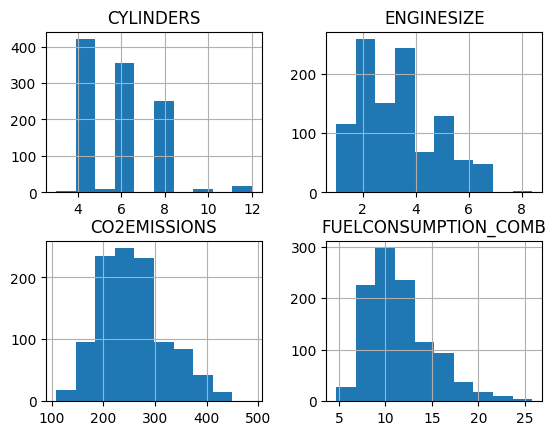

In [5]:
viz = cdf[['CYLINDERS','ENGINESIZE','CO2EMISSIONS','FUELCONSUMPTION_COMB']]
viz.hist()
plt.show()

Ahora comparamos estas características con la emisión de CO2 mediante
gráficos de dispersión, para ver **cuán lineal** es la relación.

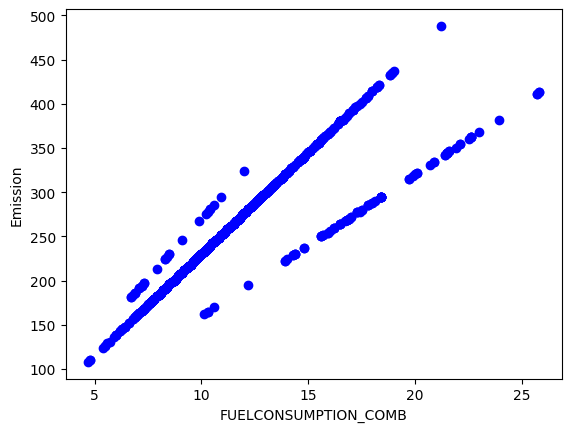

In [6]:
plt.scatter(cdf.FUELCONSUMPTION_COMB, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("FUELCONSUMPTION_COMB")
plt.ylabel("Emission")
plt.show()

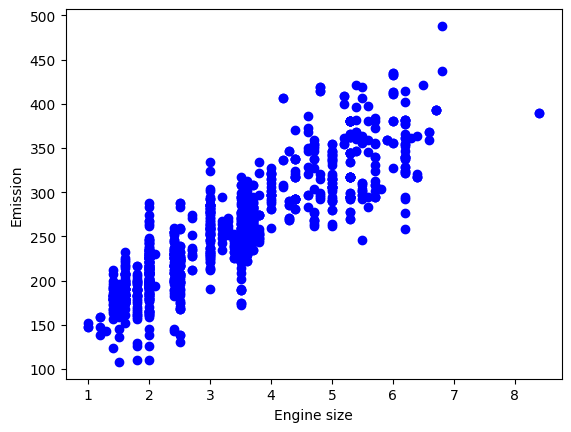

In [7]:
plt.scatter(cdf.ENGINESIZE, cdf.CO2EMISSIONS, color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

## 4. Práctica: CYLINDERS vs Emisión

Dibujamos `CYLINDERS` contra la emisión de CO2 para observar cuán lineal es su
relación.

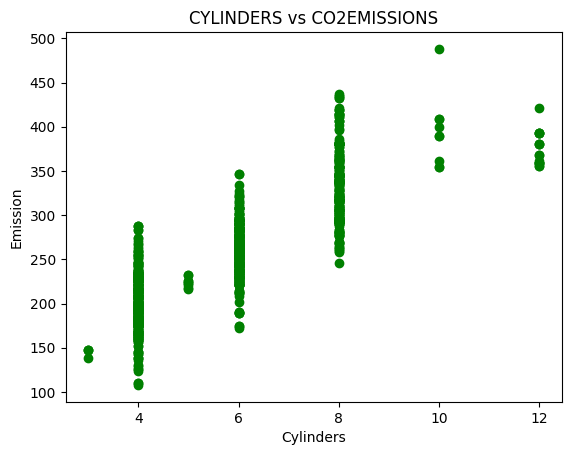

In [8]:
plt.scatter(cdf.CYLINDERS, cdf.CO2EMISSIONS, color='green')
plt.xlabel("Cylinders")
plt.ylabel("Emission")
plt.title("CYLINDERS vs CO2EMISSIONS")
plt.show()

**Observación:** Al igual que `ENGINESIZE` y `FUELCONSUMPTION_COMB`, el
número de cilindros muestra una relación claramente **positiva y aproximadamente
lineal** con las emisiones de CO2: a mayor número de cilindros, mayores
emisiones. Los datos se agrupan en valores discretos (4, 6, 8, 12 cilindros)
porque es una variable entera.

## 5. Creando el set de entrenamiento y de prueba

Hacemos un **Train/Test Split**: dividimos el dataset en dos conjuntos
mutuamente excluyentes. Aproximadamente el 80% de los datos se usa para
**entrenar** y el 20% restante para **probar**. Entrenar y probar con datos
distintos nos da una evaluación más realista del modelo (evita el
sobreajuste).

In [9]:
msk = np.random.rand(len(df)) < 0.8
train = cdf[msk]
test = cdf[~msk]

print("Total de registros:  ", len(cdf))
print("Registros de train:  ", len(train))
print("Registros de test:   ", len(test))

Total de registros:   1067
Registros de train:   848
Registros de test:    219


## 6. Modelo de Regresión Lineal Simple

La Regresión Lineal ajusta un modelo lineal con coeficientes
$B = (B_1, ..., B_n)$ para minimizar la **suma residual de cuadrados** entre la
variable independiente $x$ y la dependiente $y$ a través de la aproximación
lineal.

Usaremos `ENGINESIZE` como variable independiente para predecir `CO2EMISSIONS`.

### Distribución de los datos de entrenamiento

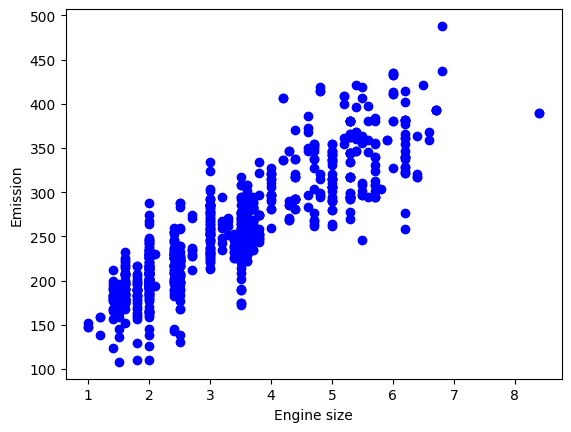

In [10]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='blue')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

### Modeling

Usamos el paquete `sklearn` para crear y entrenar el modelo.

In [11]:
from sklearn import linear_model

regr = linear_model.LinearRegression()
train_x = np.asanyarray(train[['ENGINESIZE']])
train_y = np.asanyarray(train[['CO2EMISSIONS']])
regr.fit(train_x, train_y)

# Los coeficientes
print('Coefficients: ', regr.coef_)
print('Intercept: ', regr.intercept_)

Coefficients:  [[39.526118]]
Intercept:  [124.17604844]


### Trazando las salidas

Marcamos la recta de ajuste sobre los datos de entrenamiento.

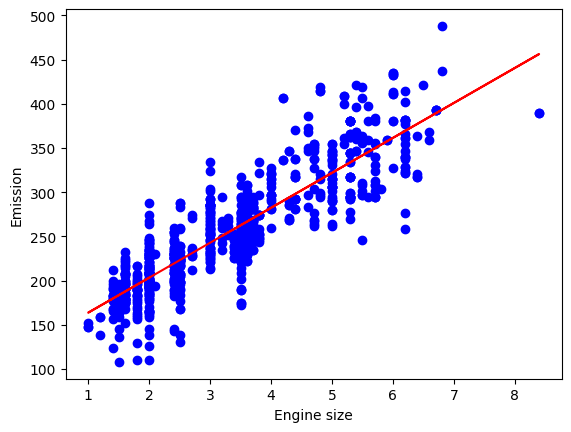

In [12]:
plt.scatter(train.ENGINESIZE, train.CO2EMISSIONS, color='blue')
plt.plot(train_x, regr.coef_[0][0]*train_x + regr.intercept_[0], '-r')
plt.xlabel("Engine size")
plt.ylabel("Emission")
plt.show()

## 7. Evaluación

Comparamos los valores **reales** y **predichos** para calcular la exactitud
del modelo sobre el conjunto de prueba. Las métricas de evaluación son clave
para conocer las áreas que necesitan mejora.

- **Error medio absoluto (MAE):** media del valor absoluto de los errores. Es
  la métrica más fácil de interpretar.
- **Error Cuadrático Medio (MSE):** media de los errores al cuadrado. Penaliza
  con más fuerza los errores grandes.
- **Raíz del Error Cuadrático Medio (RMSE):** raíz cuadrada del MSE; queda en
  las mismas unidades que la variable objetivo.
- **R² (R-cuadrado):** no es un error, sino una medida de qué tan cerca están
  los datos de la recta ajustada. Cuanto más alto (máximo 1.0), mejor se ajusta
  el modelo.

In [13]:
from sklearn.metrics import r2_score

test_x = np.asanyarray(test[['ENGINESIZE']])
test_y = np.asanyarray(test[['CO2EMISSIONS']])
test_y_ = regr.predict(test_x)

print("Error medio absoluto: %.2f" % np.mean(np.absolute(test_y_ - test_y)))
print("Suma residual de los cuadrados (MSE): %.2f" % np.mean((test_y_ - test_y) ** 2))
print("R2-score: %.2f" % r2_score(test_y_, test_y))

Error medio absoluto: 22.58
Suma residual de los cuadrados (MSE): 851.05
R2-score: 0.74


## 8. Usando el modelo para predecir valores desconocidos

Una vez entrenado, el modelo puede estimar las emisiones de CO2 para tamaños de
motor que no estaban en los datos.

In [14]:
nuevos_motores = np.array([[2.0], [3.5], [5.0], [6.2]])
predicciones = regr.predict(nuevos_motores)

for tam, pred in zip(nuevos_motores.ravel(), predicciones.ravel()):
    print(f"Motor de {tam:.1f} L  ->  CO2 estimado: {pred:.1f} g/km")

Motor de 2.0 L  ->  CO2 estimado: 203.2 g/km
Motor de 3.5 L  ->  CO2 estimado: 262.5 g/km
Motor de 5.0 L  ->  CO2 estimado: 321.8 g/km
Motor de 6.2 L  ->  CO2 estimado: 369.2 g/km


## Entregables

### a) Resultados de la ejecución de los comandos

Todas las celdas anteriores se ejecutaron correctamente: se cargó el dataset
(1067 registros), se generaron los histogramas y diagramas de dispersión, se
dividieron los datos en entrenamiento (~80%) y prueba (~20%), y se entrenó el
modelo de regresión lineal simple sobre `ENGINESIZE` → `CO2EMISSIONS`.

### b) Polinomio generado por el modelo de regresión

El modelo de regresión lineal simple tiene la forma:

$$\hat{y} = B_1 \cdot x + B_0$$

donde $x$ = `ENGINESIZE` y $\hat{y}$ = `CO2EMISSIONS` estimadas. La siguiente
celda imprime la **ecuación concreta** con los coeficientes obtenidos.

In [15]:
b1 = regr.coef_[0][0]      # pendiente
b0 = regr.intercept_[0]    # intercepto

print("Ecuación del modelo de regresión:")
print(f"CO2EMISSIONS = {b1:.2f} * ENGINESIZE + {b0:.2f}")

Ecuación del modelo de regresión:
CO2EMISSIONS = 39.53 * ENGINESIZE + 124.18


### c) Análisis de la precisión del modelo

- El valor de **R²** indica qué proporción de la variabilidad en las emisiones
  de CO2 queda explicada por el tamaño del motor. Un R² alto (cercano a 1)
  muestra que `ENGINESIZE` es un buen predictor por sí solo.
- El **MAE** se interpreta directamente en g/km: es el error promedio entre la
  emisión real y la predicha.
- El **MSE** penaliza más los errores grandes, por lo que es útil para detectar
  predicciones muy alejadas.

**Conclusión:** existe una relación lineal positiva fuerte entre el tamaño del
motor y las emisiones de CO2. El modelo simple captura bien la tendencia
general, aunque podría mejorarse usando regresión lineal **múltiple**
(combinando `ENGINESIZE`, `CYLINDERS` y `FUELCONSUMPTION_COMB`) o regresión
**polinómica**, ya que parte de la dispersión no queda explicada por una sola
variable.